# C1 Relevant Parameters — fixed depths, 25D / 8 relevant

Depth sweep with 25 total parameters, 8 relevant quadratic parameters, and 17 noisy/irrelevant parameters.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "02_25d_8_relevant":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/c1_relevant_parameters/depth_policies/02_25d_8_relevant")
OUTPUT_DIRECTORY = HERE / "smac_output"
DEPTHS = (3, 6, 9, 12, 15, 20)
POLICIES = tuple(f"fixed_depth_{depth}" for depth in DEPTHS)
SEEDS = tuple(range(5))
N_TRIALS = 1000
N_INSTANCES = 10
DIMENSION = 25
NUM_QUADRATIC = 8
NUM_NOISY = 17
PROBLEM_SEED = 52
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_depth_{depth}": f"depth = {depth}" for depth in DEPTHS}
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4", "C5")))

In [2]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS and result["problem_seed"] == PROBLEM_SEED:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    expected_depth = int(policy.rsplit("_", 1)[1])
    for result in runs.values():
        assert result["problem"] == "C1-RelevantParameters"
        assert result["dimension"] == DIMENSION
        assert result["num_quadratic"] == NUM_QUADRATIC
        assert result["num_noisy"] == NUM_NOISY
        assert result["n_instances"] == N_INSTANCES
        assert len(result["instance_map"]) == N_INSTANCES
        assert result["problem_seed"] == PROBLEM_SEED
        assert result["pythonhashseed"] == "12345"
        assert result["deterministic"] is False
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["max_depth"] == expected_depth
        assert result["min_samples_leaf"] == 3
        assert result["min_samples_split"] == 3
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
print(f"Loaded {sum(map(len, results.values()))}/30 validated trajectories.")

Loaded 30/30 validated trajectories.


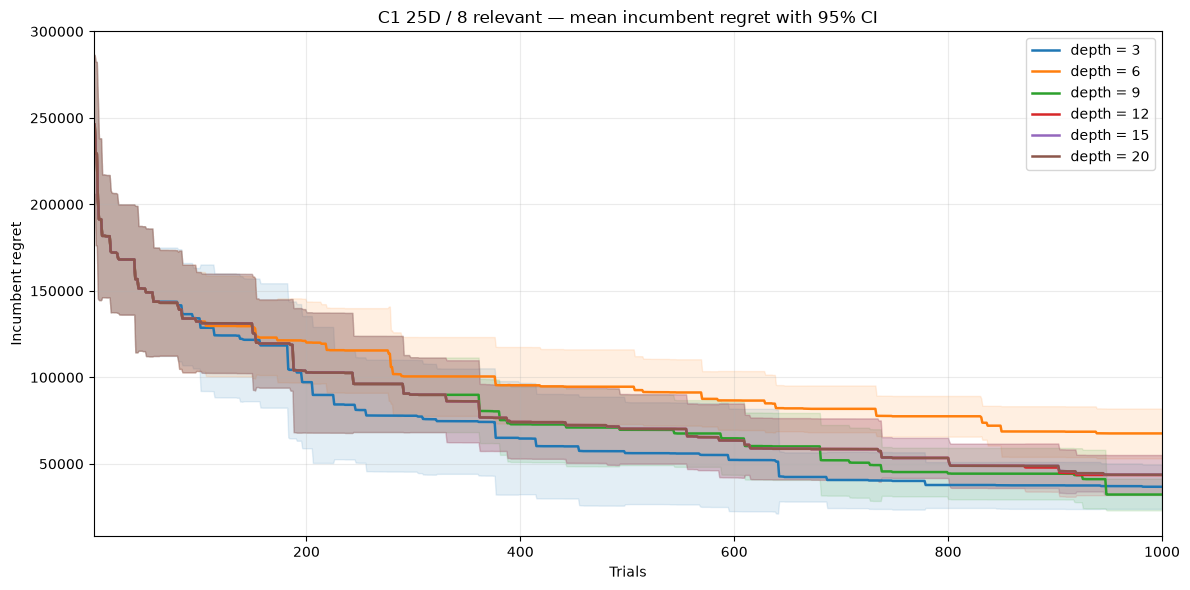

In [3]:
rows = [{"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret} for policy, runs in results.items() for seed, result in runs.items() for iteration, regret in zip(result["iteration"], result["best_regret"])]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(12, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linewidth=1.8)
    ax.fill_between(data.iteration, data["mean"] - data.ci95, data["mean"] + data.ci95, color=COLORS[policy], alpha=.12)
ax.set(title="C1 25D / 8 relevant — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS))
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

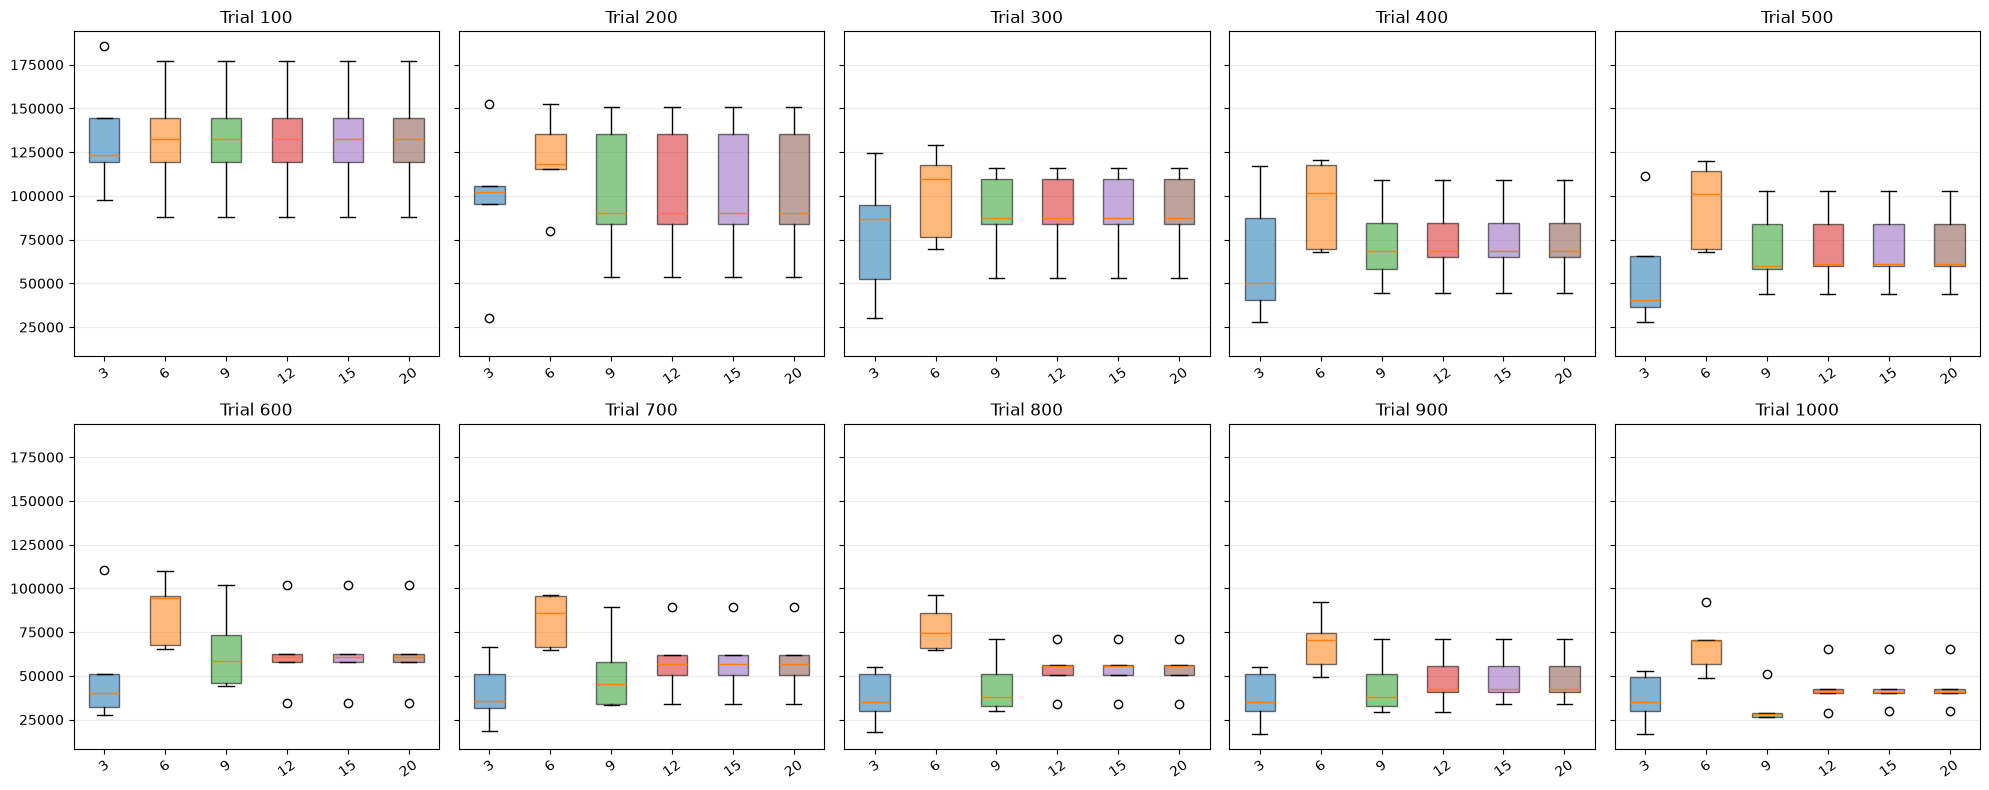

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(depth) for depth in DEPTHS])
    for box, policy in zip(boxes["boxes"], POLICIES):
        box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}"); ax.tick_params(axis="x", rotation=35); ax.grid(axis="y", alpha=.25)
plt.tight_layout(); plt.show()

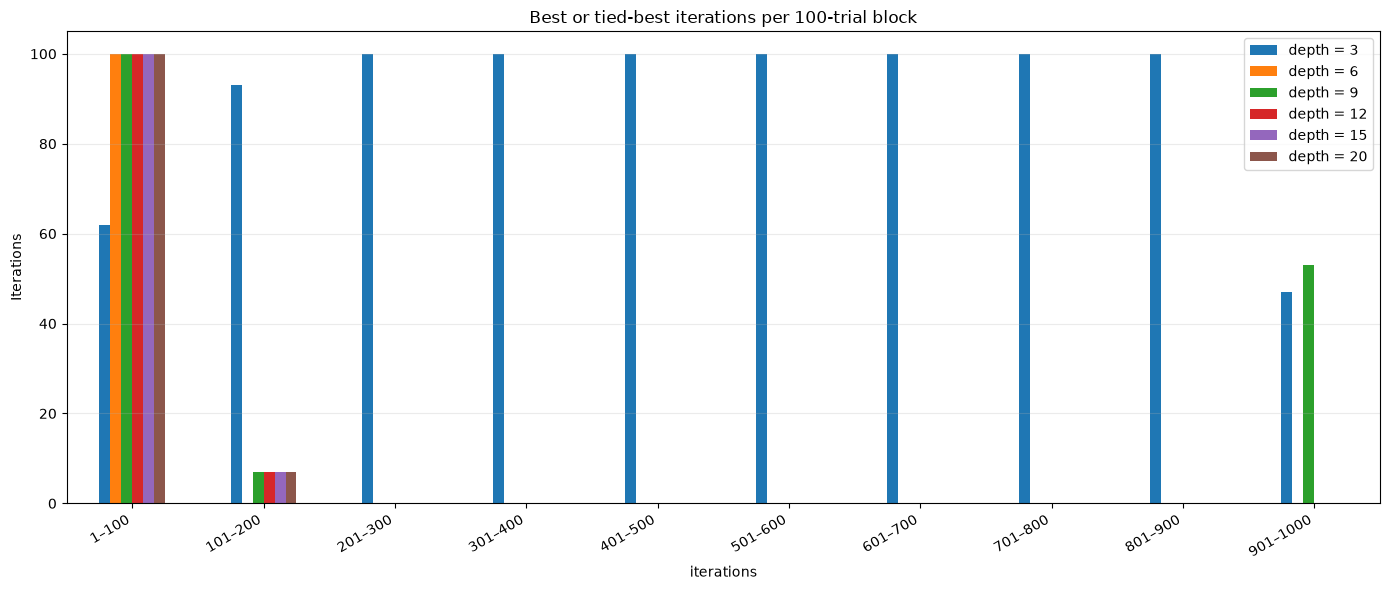

,iterations,superior policy,depth = 3,depth = 6,depth = 9,depth = 12,depth = 15,depth = 20
0,1–100,"depth = 6, depth = 9, depth = 12, depth = 15, ...",62,100,100,100,100,100
1,101–200,depth = 3,93,0,7,7,7,7
2,201–300,depth = 3,100,0,0,0,0,0
3,301–400,depth = 3,100,0,0,0,0,0
4,401–500,depth = 3,100,0,0,0,0,0
5,501–600,depth = 3,100,0,0,0,0,0
6,601–700,depth = 3,100,0,0,0,0,0
7,701–800,depth = 3,100,0,0,0,0,0
8,801–900,depth = 3,100,0,0,0,0,0
9,901–1000,depth = 9,47,0,53,0,0,0


In [5]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9) for policy in POLICIES}, index=mean_regret.index)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum(); maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[policy] for policy in POLICIES if counts[policy] == maximum)}
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES}); block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
ax = block_superiority.set_index("iterations")[[LABELS[policy] for policy in POLICIES]].plot(kind="bar", figsize=(14, 6), color=[COLORS[policy] for policy in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block", ylabel="Iterations", ylim=(0, 105)); ax.grid(axis="y", alpha=.25); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None): display(block_superiority)

In [6]:
run_rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        regret = np.asarray(result["best_regret"], dtype=float)
        run_rows.append({"policy": LABELS[policy], "seed": seed, "final_regret": regret[-1], "mean_incumbent_regret": regret.mean()})
run_metrics = pd.DataFrame(run_rows)
metric_summary = run_metrics.groupby("policy")[["final_regret", "mean_incumbent_regret"]].agg(["mean", "std", "median", "min", "max"]).sort_values(("final_regret", "mean"))
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(metric_summary)
    display(run_metrics.sort_values(["seed", "final_regret"]))

final_regret                                            \
                    mean           std        median           min   
policy                                                               
depth = 9   32243.320817  10487.113562  28132.931526  26568.637278   
depth = 3   36742.423222  14587.037139  35116.538331  16862.596522   
depth = 12  43512.063766  13256.656189  40724.312171  28849.300153   
depth = 15  43729.720908  12961.372165  40724.312171  29937.585864   
depth = 20  43729.720908  12961.372165  40724.312171  29937.585864   
depth = 6   67579.631651  16415.937524  69673.186590  49048.229528   

                         mean_incumbent_regret                               \
                     max                  mean           std         median   
policy                                                                        
depth = 9   50917.718955          79179.805283  18853.045738   73975.528038   
depth = 3   52675.542314          70838.181720  26800.887006   64123.027782   
depth = 12  65161.650741          81045.455638  20067.407595   79273.064250   
depth = 15  65161.650741          81131.199815  19941.149297   79273.064250   
depth = 20  65161.650741          81131.199815  19941.149297   79273.064250   
depth = 6   92096.538303          98397.266842  20296.832988  103623.542551   

                                         
                     min            max  
policy                                   
depth = 9   57151.838705  106972.908320  
depth = 3   38706.319133  111783.134581  
depth = 12  57308.927885  108865.499127  
depth = 15  57737.648773  108865.499127  
depth = 20  57737.648773  108865.499127  
depth = 6   74531.745245  120504.466717

,policy,seed,final_regret,mean_incumbent_regret
4,depth = 3,0,16862.596522,38706.319133
19,depth = 12,0,42567.261494,68322.400180
24,depth = 15,0,42567.261494,68322.400180
29,depth = 20,0,42567.261494,68322.400180
14,depth = 9,0,50917.718955,70628.352064
9,depth = 6,0,56596.692468,74531.745245
18,depth = 12,1,28849.300153,57308.927885
13,depth = 9,1,28933.927294,57151.838705
23,depth = 15,1,29937.585864,57737.648773
28,depth = 20,1,29937.585864,57737.648773


In [7]:
checkpoint_table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration", "policy"])["best_regret"].agg(["mean", "std", "min", "median", "max"])
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None): display(checkpoint_table)

mean           std           min  \
iteration policy                                                      
100       fixed_depth_12  132281.593422  32653.082011  88153.343006   
          fixed_depth_15  132281.593422  32653.082011  88153.343006   
          fixed_depth_20  132281.593422  32653.082011  88153.343006   
          fixed_depth_3   134119.419477  33146.836480  97870.467017   
          fixed_depth_6   132281.593422  32653.082011  88153.343006   
          fixed_depth_9   132281.593422  32653.082011  88153.343006   
200       fixed_depth_12  102836.201398  39698.634930  53596.374073   
          fixed_depth_15  102836.201398  39698.634930  53596.374073   
          fixed_depth_20  102836.201398  39698.634930  53596.374073   
          fixed_depth_3    97212.044728  43610.118708  30398.440514   
          fixed_depth_6   120132.257109  27044.187712  79672.450385   
          fixed_depth_9   102836.201398  39698.634930  53596.374073   
300       fixed_depth_12   89991.273888  24704.347781  53304.047489   
          fixed_depth_15   89991.273888  24704.347781  53304.047489   
          fixed_depth_20   89991.273888  24704.347781  53304.047489   
          fixed_depth_3    77806.626379  36868.287425  30277.104401   
          fixed_depth_6   100533.301942  26012.852773  69887.211303   
          fixed_depth_9    89991.273888  24704.347781  53304.047489   
400       fixed_depth_12   74181.972188  24101.295902  44374.776207   
          fixed_depth_15   74181.972188  24101.295902  44374.776207   
          fixed_depth_20   74181.972188  24101.295902  44374.776207   
          fixed_depth_3    64626.754642  36737.577312  27898.918291   
          fixed_depth_6    95428.190185  25236.994801  68064.200301   
          fixed_depth_9    72869.610282  24889.742879  44374.776207   
500       fixed_depth_12   70249.670032  22983.199641  43914.093088   
          fixed_depth_15   70249.670032  22983.199641  43914.093088   
          fixed_depth_20   70249.670032  22983.199641  43914.093088   
          fixed_depth_3    56228.043847  33718.773957  27803.777939   
          fixed_depth_6    94582.330465  24625.016971  67798.191287   
          fixed_depth_9    69683.597501  23299.541873  43914.093088   
600       fixed_depth_12   63503.509092  24376.939109  34488.590802   
          fixed_depth_15   63503.509092  24376.939109  34488.590802   
          fixed_depth_20   63503.509092  24376.939109  34488.590802   
          fixed_depth_3    52249.046761  33788.513882  27347.581261   
          fixed_depth_6    86663.165684  19396.733025  65156.510644   
          fixed_depth_9    64730.742842  24025.431721  43914.093088   
700       fixed_depth_12   58508.082158  20254.400557  34063.275230   
          fixed_depth_15   58508.082158  20254.400557  34063.275230   
          fixed_depth_20   58508.082158  20254.400557  34063.275230   
          fixed_depth_3    40671.932697  18519.039831  18615.352460   
          fixed_depth_6    81795.688272  15394.985078  64731.195072   
          fixed_depth_9    52032.223132  23292.922236  33227.609606   
800       fixed_depth_12   53407.771005  13238.648644  33998.367965   
          fixed_depth_15   53407.771005  13238.648644  33998.367965   
          fixed_depth_20   53407.771005  13238.648644  33998.367965   
          fixed_depth_3    37760.024153  15141.033669  18026.514432   
          fixed_depth_6    77490.157702  13408.043599  64666.287807   
          fixed_depth_9    44419.332676  16851.677723  29634.835087   
900       fixed_depth_12   47842.625088  15964.800332  29048.543469   
          fixed_depth_15   48832.589988  14603.468743  33998.367965   
          fixed_depth_20   48832.589988  14603.468743  33998.367965   
          fixed_depth_3    37554.714447  15478.706782  16999.965902   
          fixed_depth_6    68672.815628  16705.550076  49185.598907   
          fixed_depth_9    44304.563188  16979.014263  29060.987643   
1000      fixed_depth_12   43512.063766  13256.656189  2884